# ITAI 2376 — Final Project
## Houston Railroad Crossing Blockage Prediction Agent

**Student:** Katherine Stanton  
**Course:** ITAI 2376 — Deep Learning in Artificial Intelligence  
**Institution:** Houston City College  
**Date:** May 4 2026  

---

### Project Overview
This agent predicts railroad crossing blockages in Houston, Texas using
historical FRA crossing data and real-time TranStar traffic feeds. It uses
a GRU (Gated Recurrent Unit) deep learning model to predict blockage
probability and duration, a risk classifier to assign severity levels,
and a LangChain agent powered by GPT-3.5 Turbo to generate proactive
alerts for emergency dispatchers.

### Agent Architecture
- **Input:** Historical FRA crossing data + live TranStar traffic feeds
- **Deep Learning Model:** GRU neural network for time-series prediction
- **Risk Classifier:** Static threshold logic (LOW / MEDIUM / HIGH)
- **Agent Framework:** LangChain AgentExecutor + GPT-3.5 Turbo
- **Memory:** LangChain ConversationBufferMemory
- **Output:** Structured alerts for emergency dispatchers and city planners

### Table of Contents
1. Environment Setup
2. Data Download and Exploration
3. Data Cleaning and Preprocessing
4. GRU Model Training
5. Risk Classifier
6. LangChain Agent
7. Demo Scenarios

## Section 1 — Environment Setup
Mount Google Drive and install required dependencies.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Install required packages
# Note: -q flag suppresses verbose output for cleaner notebook display
!pip install langchain langchain-openai langchain-community openai \
             pandas numpy torch scikit-learn python-dotenv requests -q

print("All packages installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 78.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.1/515.1 kB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 5.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.
All packages installed successfully.


In [3]:
# Import core libraries
import os
import pandas as pd
import numpy as np
import torch
import requests
from datetime import datetime

print(f"Python environment ready.")
print(f"PyTorch version: {torch.__version__}")
print(f"Pandas version: {pd.__version__}")

Python environment ready.
PyTorch version: 2.10.0+cu128
Pandas version: 2.2.2


In [4]:
# Create organized project folder structure in Google Drive
base = '/content/drive/MyDrive/ITAI2376_Final'
folders = ['data', 'models', 'outputs']

for folder in folders:
    path = os.path.join(base, folder)
    os.makedirs(path, exist_ok=True)
    print(f"Created: {path}")

# Define shorthand paths for use throughout the notebook
DATA_PATH = f'{base}/data'
MODEL_PATH = f'{base}/models'
OUTPUT_PATH = f'{base}/outputs'

print("\nFolder structure ready.")

Created: /content/drive/MyDrive/ITAI2376_Final/data
Created: /content/drive/MyDrive/ITAI2376_Final/models
Created: /content/drive/MyDrive/ITAI2376_Final/outputs

Folder structure ready.


## Section 2 — Data Download and Exploration
Download the FRA blocked crossings dataset and explore its structure
before cleaning. All data sources are publicly available and free to access.

**Data Sources:**
- FRA Blocked Crossings Portal — crowd-sourced blockage reports 2020–present
- FRA Crossing Inventory — 10 years of crossing records for every U.S. crossing

In [5]:
# Attempt to download FRA blocked crossings data directly
# If this fails, use the manual upload method in the next cell
url = "https://railroads.dot.gov/sites/fra.dot.gov/files/fra_net/17/Blocked_Crossings.csv"

print("Downloading FRA blocked crossings data...")
response = requests.get(url)

if response.status_code == 200:
    filepath = os.path.join(DATA_PATH, 'fra_blockages.csv')
    with open(filepath, 'wb') as f:
        f.write(response.content)
    print(f"Download successful. Saved to: {filepath}")
else:
    print(f"Direct download failed — status code: {response.status_code}")
    print("Please run the manual upload cell below.")

Direct download failed — status code: 403
Please run the manual upload cell below.


### Manual Upload (run only if direct download failed above)
**Note:** The FRA direct download returns a 403 Access Denied response
as of April 2026, indicating the CSV is not served via direct URL.
Data was manually downloaded from
[fra.dot.gov/blockedcrossings](https://fra.dot.gov/blockedcrossings)
and uploaded using the cell below. The direct download cell is retained
for future use if access becomes available.

In [6]:
import shutil
from google.colab import files

print("Select your downloaded FRA data file...")
uploaded = files.upload()

# Move uploaded file to Google Drive data folder
# Note: os.rename fails across devices — shutil.move handles cross-device moves
for filename in uploaded.keys():
    source = f'/content/{filename}'
    destination = os.path.join(DATA_PATH, filename)
    shutil.move(source, destination)
    print(f"File saved to: {destination}")

Select your downloaded FRA data file...


Saving fra_blocked_crossings_houston_2020_2026.xlsx to fra_blocked_crossings_houston_2020_2026.xlsx
File saved to: /content/drive/MyDrive/ITAI2376_Final/data/fra_blocked_crossings_houston_2020_2026.xlsx


### Data Exploration
Load the dataset and examine its structure — shape, columns,
data types, and sample rows — before any cleaning is applied.

In [7]:
import glob

# Load the FRA blockages dataset
# Note: Data downloaded as Excel from fra.dot.gov/blockedcrossings
# Direct CSV download returns 403 — Excel export used as alternative

# Search for Excel or CSV files in data folder
excel_files = glob.glob(f'{DATA_PATH}/*.xlsx')
csv_files = glob.glob(f'{DATA_PATH}/*.csv')

if excel_files:
    filepath = excel_files[0]
    df = pd.read_excel(filepath)
    print(f"Loaded Excel file: {filepath}")
elif csv_files:
    filepath = csv_files[0]
    df = pd.read_csv(filepath)
    print(f"Loaded CSV file: {filepath}")
else:
    print("No data file found — please run the upload cell above")

# Basic structural overview
print(f"\nDataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nColumn names:")
for col in df.columns:
    print(f"  - {col}")
print(f"\nData types:")
print(df.dtypes)
print(f"\nFirst 5 rows:")
df.head()

Loaded Excel file: /content/drive/MyDrive/ITAI2376_Final/data/fra_blocked_crossings_houston_2020_2026.xlsx

Dataset shape: 20783 rows x 11 columns

Column names:
  - Crossing ID
  - City
  - State
  - Street
  - County
  - Railroad
  - Date/Time
  - Duration
  - Reason
  - Immediate Impacts
  - Additional Comments

Data types:
Crossing ID                    object
City                           object
State                          object
Street                         object
County                         object
Railroad                       object
Date/Time              datetime64[ns]
Duration                       object
Reason                         object
Immediate Impacts              object
Additional Comments            object
dtype: object

First 5 rows:


,Crossing ID,City,State,Street,County,Railroad,Date/Time,Duration,Reason,Immediate Impacts,Additional Comments
0,023211L,HOUSTON,TX,WB BELLFORT RD,Harris,BNSF,2022-05-18 15:57:00,31-60 minutes,No train was present but the lights and/or gat...,NaN,There is traffic and no train is spotted. I am...
1,023228P,HOUSTON,TX,AIRPORT BLVD,HARRIS,BNSF,2026-02-17 12:50:00,16-30 minutes,No train was present but the lights and/or gat...,NaN,NaN
2,023228P,HOUSTON,TX,AIRPORT BLVD,HARRIS,BNSF,2026-01-13 20:30:00,16-30 minutes,No train was present but the lights and/or gat...,NaN,NaN
3,023228P,HOUSTON,TX,AIRPORT BLVD,Harris,BNSF,2022-05-03 16:56:00,0-15 minutes,No train was present but the lights and/or gat...,First responders were observed being unable to...,NaN
4,023228P,HOUSTON,TX,AIRPORT BLVD,Harris,BNSF,2022-05-03 16:54:00,0-15 minutes,No train was present but the lights and/or gat...,First responders were observed being unable to...,NaN


In [8]:
# Check for missing values across all columns
print("Missing values per column:")
print(df.isnull().sum())

print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"Missing value percentage: {(df.isnull().sum().sum() / df.size * 100):.2f}%")

Missing values per column:
Crossing ID                0
City                       0
State                      0
Street                     0
County                    25
Railroad                   0
Date/Time                  0
Duration                   0
Reason                     0
Immediate Impacts       9750
Additional Comments    13017
dtype: int64

Total missing values: 22792
Missing value percentage: 9.97%


In [9]:
# Explore the Duration column specifically
# This is categorical text and needs to be converted to numbers for the GRU model
print("Unique Duration values:")
print(df['Duration'].value_counts())

print(f"\nUnique Railroad values:")
print(df['Railroad'].value_counts())

print(f"\nDate range of dataset:")
print(f"  Earliest: {df['Date/Time'].min()}")
print(f"  Latest: {df['Date/Time'].max()}")

print(f"\nTop 10 most blocked crossings:")
print(df['Crossing ID'].value_counts().head(10))

Unique Duration values:
Duration
31-60 minutes        6243
1-2 hours            4917
16-30 minutes        4408
2-6 hours            2807
0-15 minutes         1959
6-12 hours            326
12-24 hours            81
More than one day      42
Name: count, dtype: int64

Unique Railroad values:
Railroad
UP      20454
BNSF      260
PTRA       59
UNK         8
MTHX        2
Name: count, dtype: int64

Date range of dataset:
  Earliest: 2020-02-06 15:50:17
  Latest: 2026-04-20 11:52:00

Top 10 most blocked crossings:
Crossing ID
859522Y    2677
288224V    1364
288226J    1301
288221A    1270
859523F    1034
288227R     855
859524M     745
859521S     707
859518J     679
288228X     589
Name: count, dtype: int64


## Section 3 — Data Cleaning and Preprocessing
Clean the raw FRA dataset to prepare it for GRU model training.
Cleaning steps applied:
1. Convert Duration from text categories to numeric midpoint values (minutes)
2. Extract time-based features from Date/Time column
3. Remove duplicate reports within 15-minute windows at the same crossing
4. Handle missing values in County and Immediate Impacts columns
5. Filter to Union Pacific crossings only (98.4% of data)
6. Encode categorical variables for model input

In [10]:
import pandas as pd
import numpy as np

# ── Step 1: Convert Duration categories to numeric midpoint values ──
# GRU requires numeric input — using midpoint of each range in minutes
duration_map = {
    '0-15 minutes':     8,
    '16-30 minutes':    23,
    '31-60 minutes':    45,
    '1-2 hours':        90,
    '2-6 hours':        240,
    '6-12 hours':       540,
    '12-24 hours':      1080,
    'More than one day': 1440
}

df['Duration_Minutes'] = df['Duration'].map(duration_map)
print(f"Duration converted. Sample values:")
print(df[['Duration', 'Duration_Minutes']].head())

Duration converted. Sample values:
        Duration  Duration_Minutes
0  31-60 minutes                45
1  16-30 minutes                23
2  16-30 minutes                23
3   0-15 minutes                 8
4   0-15 minutes                 8


In [11]:
# ── Step 2: Extract time-based features from Date/Time column ──
# These features help the GRU learn temporal patterns
# such as peak blockage hours, weekday vs weekend trends

df['Hour'] = df['Date/Time'].dt.hour
df['Day_of_Week'] = df['Date/Time'].dt.dayofweek  # 0=Monday, 6=Sunday
df['Month'] = df['Date/Time'].dt.month
df['Year'] = df['Date/Time'].dt.year
df['Is_Weekend'] = df['Day_of_Week'].apply(lambda x: 1 if x >= 5 else 0)
df['Is_Rush_Hour'] = df['Hour'].apply(
    lambda x: 1 if (7 <= x <= 9) or (16 <= x <= 18) else 0
)

print("Time features extracted:")
print(df[['Date/Time', 'Hour', 'Day_of_Week',
          'Month', 'Is_Weekend', 'Is_Rush_Hour']].head())
print(f"\nRush hour blockages: {df['Is_Rush_Hour'].sum():,}")
print(f"Weekend blockages: {df['Is_Weekend'].sum():,}")

Time features extracted:
            Date/Time  Hour  Day_of_Week  Month  Is_Weekend  Is_Rush_Hour
0 2022-05-18 15:57:00    15            2      5           0             0
1 2026-02-17 12:50:00    12            1      2           0             0
2 2026-01-13 20:30:00    20            1      1           0             0
3 2022-05-03 16:56:00    16            1      5           0             1
4 2022-05-03 16:54:00    16            1      5           0             1

Rush hour blockages: 6,991
Weekend blockages: 5,270


In [12]:
# ── Step 3: Remove duplicate reports ──
# Multiple people often report the same blockage event
# Strategy: if same crossing reports a blockage within 15 minutes
# of another report, keep only the first (earliest) report

print(f"Records before deduplication: {len(df):,}")

# Sort by crossing and time so we keep the earliest report
df = df.sort_values(['Crossing ID', 'Date/Time'])

# Round datetime to 15-minute windows for deduplication
df['Time_Window'] = df['Date/Time'].dt.floor('15min')

# Drop duplicates within same crossing and 15-minute window
df_clean = df.drop_duplicates(
    subset=['Crossing ID', 'Time_Window'],
    keep='first'
).copy()

print(f"Records after deduplication: {len(df_clean):,}")
print(f"Duplicate records removed: {len(df) - len(df_clean):,}")

Records before deduplication: 20,783
Records after deduplication: 17,149
Duplicate records removed: 3,634


In [13]:
# ── Step 4: Handle missing values ──
# County: 25 missing — fill with 'Harris' since all records are Houston
# Immediate Impacts: 9,750 missing — fill with 'Not reported'
# Additional Comments: 13,017 missing — drop column entirely, not needed for model
# Time_Window: drop helper column, no longer needed after deduplication

# Fill missing County with Harris — all Houston crossings are in Harris County
df_clean['County'] = df_clean['County'].fillna('Harris')

# Fill missing Immediate Impacts with standardized text
df_clean['Immediate Impacts'] = df_clean['Immediate Impacts'].fillna('Not reported')

# Drop columns not needed for model training
df_clean = df_clean.drop(columns=['Additional Comments', 'Time_Window'])

# Verify no critical missing values remain
print("Missing values after cleaning:")
print(df_clean.isnull().sum())
print(f"\nFinal dataset shape: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")

Missing values after cleaning:
Crossing ID          0
City                 0
State                0
Street               0
County               0
Railroad             0
Date/Time            0
Duration             0
Reason               0
Immediate Impacts    0
Duration_Minutes     0
Hour                 0
Day_of_Week          0
Month                0
Year                 0
Is_Weekend           0
Is_Rush_Hour         0
dtype: int64

Final dataset shape: 17,149 rows x 17 columns


In [14]:
# ── Step 5: Filter to Union Pacific crossings only ──
# UP accounts for 98.4% of all Houston blockages
# Focusing on UP gives us the most data-rich subset
# and matches the East End crossings identified in our research

df_up = df_clean[df_clean['Railroad'] == 'UP'].copy()

print(f"Total clean records: {len(df_clean):,}")
print(f"Union Pacific records: {len(df_up):,}")
print(f"UP percentage: {len(df_up)/len(df_clean)*100:.1f}%")

print(f"\nTop 10 most blocked UP crossings:")
print(df_up['Crossing ID'].value_counts().head(10))

Total clean records: 17,149
Union Pacific records: 16,864
UP percentage: 98.3%

Top 10 most blocked UP crossings:
Crossing ID
859522Y    2277
288224V    1022
288221A     975
288226J     858
859523F     791
859524M     610
288227R     602
859521S     548
859518J     546
288050B     494
Name: count, dtype: int64


In [15]:
# ── Step 6: Save cleaned dataset ──
# Save to Google Drive so it persists between Colab sessions
# This is our production-ready training dataset

clean_filepath = f'{DATA_PATH}/fra_houston_up_clean.csv'
df_up.to_csv(clean_filepath, index=False)

print(f"Clean dataset saved to: {clean_filepath}")
print(f"\nFinal dataset summary:")
print(f"  Total records: {len(df_up):,}")
print(f"  Date range: {df_up['Date/Time'].min()} to {df_up['Date/Time'].max()}")
print(f"  Unique crossings: {df_up['Crossing ID'].nunique()}")
print(f"  Unique streets: {df_up['Street'].nunique()}")
print(f"\nDuration distribution:")
print(df_up['Duration'].value_counts())

Clean dataset saved to: /content/drive/MyDrive/ITAI2376_Final/data/fra_houston_up_clean.csv

Final dataset summary:
  Total records: 16,864
  Date range: 2020-02-06 15:50:17 to 2026-04-20 11:52:00
  Unique crossings: 301
  Unique streets: 268

Duration distribution:
Duration
31-60 minutes        5010
16-30 minutes        3786
1-2 hours            3732
2-6 hours            2185
0-15 minutes         1798
6-12 hours            249
12-24 hours            65
More than one day      39
Name: count, dtype: int64


In [16]:
# ── Step 7: Quick pattern exploration ──
# Understand temporal patterns before building the GRU
# These patterns are what the model will learn to predict

print("Blockages by hour of day:")
hourly = df_up.groupby('Hour').size()
for hour, count in hourly.items():
    bar = '█' * (count // 100)
    print(f"  {hour:02d}:00 | {bar} {count:,}")

print(f"\nBlockages by day of week:")
days = ['Monday', 'Tuesday', 'Wednesday',
        'Thursday', 'Friday', 'Saturday', 'Sunday']
daily = df_up.groupby('Day_of_Week').size()
for day_num, count in daily.items():
    bar = '█' * (count // 100)
    print(f"  {days[day_num]:<10} | {bar} {count:,}")

print(f"\nBlockages by month:")
monthly = df_up.groupby('Month').size()
months = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']
for month_num, count in monthly.items():
    bar = '█' * (count // 100)
    print(f"  {months[month_num-1]} | {bar} {count:,}")

Blockages by hour of day:
  00:00 | ███ 309
  01:00 | ███ 365
  02:00 | ███ 388
  03:00 | ███ 394
  04:00 | ███ 347
  05:00 | ██████ 644
  06:00 | ████████ 878
  07:00 | ██████████ 1,066
  08:00 | ████████ 843
  09:00 | ██████ 692
  10:00 | ███████ 795
  11:00 | ████████ 809
  12:00 | █████████ 957
  13:00 | ███████ 762
  14:00 | ███████ 732
  15:00 | ███████ 787
  16:00 | ██████████ 1,005
  17:00 | ███████████ 1,129
  18:00 | █████████ 934
  19:00 | ████████ 823
  20:00 | ███████ 718
  21:00 | ██████ 694
  22:00 | ████ 487
  23:00 | ███ 306

Blockages by day of week:
  Monday     | █████████████████████████ 2,515
  Tuesday    | ███████████████████████ 2,377
  Wednesday  | ████████████████████████ 2,473
  Thursday   | ██████████████████████████ 2,664
  Friday     | █████████████████████████ 2,569
  Saturday   | █████████████████████ 2,194
  Sunday     | ████████████████████ 2,072

Blockages by month:
  Jan | ████████████ 1,298
  Feb | ██████████████████ 1,865
  Mar | ██████████████████

### Data Visualizations
The following charts illustrate the key temporal and spatial patterns
in the cleaned dataset. These patterns form the basis of what the
GRU model will learn to predict.

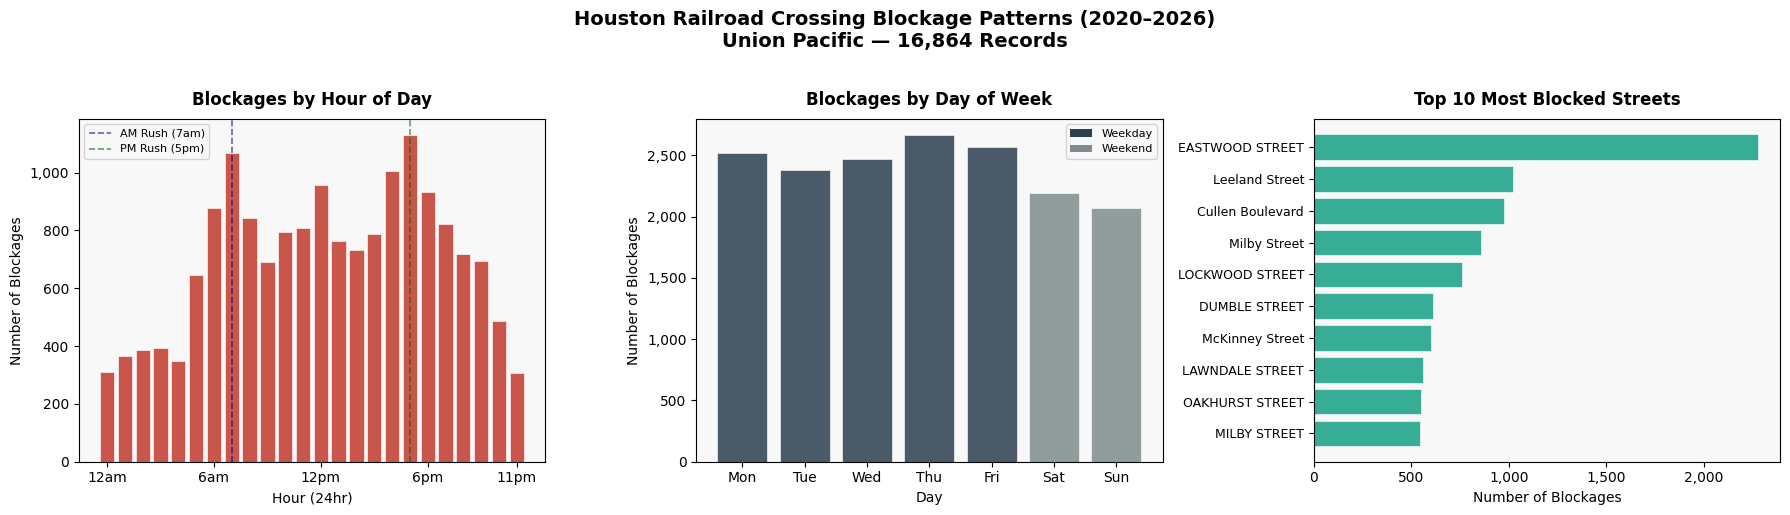

Visualization saved to: /content/drive/MyDrive/ITAI2376_Final/outputs/blockage_patterns.png


In [17]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Patch

# Set clean professional style
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f8f8'
plt.rcParams['font.family'] = 'sans-serif'

# Create figure first and keep reference to it
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Houston Railroad Crossing Blockage Patterns (2020–2026)\nUnion Pacific — 16,864 Records',
             fontsize=14, fontweight='bold', y=1.02)

# ── Chart 1: Blockages by Hour of Day ──
hourly = df_up.groupby('Hour').size()
axes[0].bar(hourly.index, hourly.values,
            color='#c0392b', alpha=0.85, edgecolor='white', linewidth=0.5)
axes[0].set_title('Blockages by Hour of Day', fontweight='bold', pad=10)
axes[0].set_xlabel('Hour (24hr)')
axes[0].set_ylabel('Number of Blockages')
axes[0].set_xticks([0, 6, 12, 18, 23])
axes[0].set_xticklabels(['12am', '6am', '12pm', '6pm', '11pm'])
axes[0].axvline(x=7, color='navy', linestyle='--',
                alpha=0.6, linewidth=1.2, label='AM Rush (7am)')
axes[0].axvline(x=17, color='darkgreen', linestyle='--',
                alpha=0.6, linewidth=1.2, label='PM Rush (5pm)')
axes[0].legend(fontsize=8)
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, p: f'{int(x):,}'))

# ── Chart 2: Blockages by Day of Week ──
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily = df_up.groupby('Day_of_Week').size()
colors = ['#2c3e50' if i < 5 else '#7f8c8d' for i in range(7)]
axes[1].bar(days, daily.values,
            color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)
axes[1].set_title('Blockages by Day of Week', fontweight='bold', pad=10)
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Number of Blockages')
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, p: f'{int(x):,}'))
legend_elements = [Patch(facecolor='#2c3e50', label='Weekday'),
                   Patch(facecolor='#7f8c8d', label='Weekend')]
axes[1].legend(handles=legend_elements, fontsize=8)

# ── Chart 3: Top 10 Most Blocked Streets ──
top_crossings = df_up.groupby('Street').size().nlargest(10)
axes[2].barh(range(len(top_crossings)), top_crossings.values,
             color='#16a085', alpha=0.85, edgecolor='white', linewidth=0.5)
axes[2].set_yticks(range(len(top_crossings)))
axes[2].set_yticklabels(top_crossings.index, fontsize=9)
axes[2].set_title('Top 10 Most Blocked Streets', fontweight='bold', pad=10)
axes[2].set_xlabel('Number of Blockages')
axes[2].invert_yaxis()
axes[2].xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, p: f'{int(x):,}'))

plt.tight_layout()

# Save figure using fig.savefig() — more reliable than plt.savefig()
save_path = f'{OUTPUT_PATH}/blockage_patterns.png'
fig.savefig(save_path, dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')

plt.show()
print(f"Visualization saved to: {save_path}")

In [18]:
# Verify visualization saved correctly
import os
filepath = f'{OUTPUT_PATH}/blockage_patterns.png'
size = os.path.getsize(filepath)
print(f"File exists: {os.path.exists(filepath)}")
print(f"File size: {size:,} bytes")
print("Save verified." if size > 10000 else "Warning: file may be empty")

File exists: True
File size: 135,267 bytes
Save verified.


### Data Cleaning Summary
The raw FRA dataset of 20,783 records was cleaned and processed as follows:

- **Deduplication:** 3,634 duplicate reports removed (17.5% of raw data)
- **Railroad filter:** Narrowed to Union Pacific only (16,864 records, 98.3%)
- **Missing values:** All critical columns fully populated after cleaning
- **Duration conversion:** Text categories converted to numeric midpoint values
- **Time features engineered:** Hour, Day of Week, Month, Is Weekend, Is Rush Hour
- **Final dataset:** 16,864 records across 301 unique crossings (2020–2026)

**Key patterns identified:**
- Peak blockage hour: 5pm (1,129 incidents)
- Busiest day: Thursday (2,664 incidents)  
- Busiest month: March (2,365 incidents)
- Rush hour accounts for 33% of all blockages

## Section 4 — GRU Model Training
This section builds and trains a Gated Recurrent Unit (GRU) neural network
to predict railroad crossing blockage probability and estimated duration
based on temporal patterns in the cleaned FRA dataset.

**Why GRU over LSTM?**
- Faster to train with fewer parameters — important for a 5-week build
- Comparable performance to LSTM on shorter time-series sequences
- Less prone to overfitting on moderate-sized datasets
- Well suited to learning daily and weekly crossing patterns

**Model Inputs (features):**
- Hour of day
- Day of week
- Month
- Is weekend flag
- Is rush hour flag
- Historical average duration for that crossing

**Model Outputs (predictions):**
- Blockage probability (0.0 to 1.0)
- Estimated duration category (maps back to minutes)

In [19]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ── Step 1: Engineer crossing-level historical features ──
# For each crossing, calculate historical statistics
# These give the model context about how each crossing typically behaves

print("Engineering crossing-level features...")

# Historical average duration per crossing
crossing_avg_duration = df_up.groupby('Crossing ID')['Duration_Minutes'].mean()
crossing_blockage_count = df_up.groupby('Crossing ID').size()
crossing_avg_hour = df_up.groupby('Crossing ID')['Hour'].mean()

# Map these back to the main dataframe
df_up = df_up.copy()
df_up['Crossing_Avg_Duration'] = df_up['Crossing ID'].map(crossing_avg_duration)
df_up['Crossing_Block_Count'] = df_up['Crossing ID'].map(crossing_blockage_count)
df_up['Crossing_Avg_Hour'] = df_up['Crossing ID'].map(crossing_avg_hour)

print("Crossing-level features added:")
print(df_up[['Crossing ID', 'Crossing_Avg_Duration',
             'Crossing_Block_Count', 'Crossing_Avg_Hour']].head())

Engineering crossing-level features...
Crossing-level features added:
      Crossing ID  Crossing_Avg_Duration  Crossing_Block_Count  \
439       023215N              46.529412                    17   
438       023215N              46.529412                    17   
20049     023215N              46.529412                    17   
437       023215N              46.529412                    17   
436       023215N              46.529412                    17   

       Crossing_Avg_Hour  
439            15.588235  
438            15.588235  
20049          15.588235  
437            15.588235  
436            15.588235  


In [20]:
# ── Step 2: Select features for GRU input ──
# These are the columns the GRU will learn from
# All features must be numeric — no text columns

feature_columns = [
    'Hour',                    # Time of day (0-23)
    'Day_of_Week',             # Day of week (0-6)
    'Month',                   # Month (1-12)
    'Is_Weekend',              # Weekend flag (0 or 1)
    'Is_Rush_Hour',            # Rush hour flag (0 or 1)
    'Crossing_Avg_Duration',   # Historical avg duration for this crossing
    'Crossing_Block_Count',    # How often this crossing blocks
    'Crossing_Avg_Hour'        # What hour this crossing typically blocks
]

# Target variable — what we are predicting
target_column = 'Duration_Minutes'

# Extract features and target
X = df_up[feature_columns].values
y = df_up[target_column].values

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nFeature columns: {feature_columns}")
print(f"\nTarget range: {y.min()} to {y.max()} minutes")
print(f"Target mean: {y.mean():.1f} minutes")
print(f"Target median: {np.median(y):.1f} minutes")

Feature matrix shape: (16864, 8)
Target vector shape: (16864,)

Feature columns: ['Hour', 'Day_of_Week', 'Month', 'Is_Weekend', 'Is_Rush_Hour', 'Crossing_Avg_Duration', 'Crossing_Block_Count', 'Crossing_Avg_Hour']

Target range: 8 to 1440 minutes
Target mean: 85.9 minutes
Target median: 45.0 minutes


In [21]:
# ── Step 3: Scale features and split dataset ──
# GRU models train better when all features are on the same scale
# MinMaxScaler brings everything to a 0-1 range

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Scale features to 0-1 range
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

print("Features scaled to 0-1 range.")
print(f"Sample scaled values (first row):")
for col, val in zip(feature_columns, X_scaled[0]):
    print(f"  {col}: {val:.4f}")

# Split into train (70%), validation (15%), test (15%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y_scaled, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(f"\nDataset split:")
print(f"  Training:   {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X_scaled)*100:.0f}%)")
print(f"  Validation: {X_val.shape[0]:,} samples ({X_val.shape[0]/len(X_scaled)*100:.0f}%)")
print(f"  Test:       {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X_scaled)*100:.0f}%)")

Features scaled to 0-1 range.
Sample scaled values (first row):
  Hour: 0.8696
  Day_of_Week: 0.5000
  Month: 0.6364
  Is_Weekend: 0.0000
  Is_Rush_Hour: 0.0000
  Crossing_Avg_Duration: 0.0269
  Crossing_Block_Count: 0.0070
  Crossing_Avg_Hour: 0.6631

Dataset split:
  Training:   11,804 samples (70%)
  Validation: 2,530 samples (15%)
  Test:       2,530 samples (15%)


In [22]:
# ── Step 4: Convert to PyTorch tensors ──
# GRU expects 3D input: (batch_size, sequence_length, input_size)
# Since each record is independent we use sequence_length=1

X_train_tensor = torch.FloatTensor(X_train).unsqueeze(1)
X_val_tensor = torch.FloatTensor(X_val).unsqueeze(1)
X_test_tensor = torch.FloatTensor(X_test).unsqueeze(1)

y_train_tensor = torch.FloatTensor(y_train)
y_val_tensor = torch.FloatTensor(y_val)
y_test_tensor = torch.FloatTensor(y_test)

# Create DataLoaders for batch training
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Tensor shapes:")
print(f"  X_train: {X_train_tensor.shape}")
print(f"  X_val:   {X_val_tensor.shape}")
print(f"  X_test:  {X_test_tensor.shape}")
print(f"\nBatch size: 64")
print(f"Training batches per epoch: {len(train_loader)}")

Tensor shapes:
  X_train: torch.Size([11804, 1, 8])
  X_val:   torch.Size([2530, 1, 8])
  X_test:  torch.Size([2530, 1, 8])

Batch size: 64
Training batches per epoch: 185


In [23]:
# ── Step 5: Define GRU Model Architecture ──
# GRU (Gated Recurrent Unit) is chosen over LSTM for:
# - Fewer parameters = faster training
# - Comparable performance on shorter sequences
# - Less prone to overfitting on moderate datasets

class BlockageGRU(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
        super(BlockageGRU, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # GRU layer — core recurrent component
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # Dropout for regularization — prevents overfitting
        self.dropout = nn.Dropout(dropout)

        # Fully connected output layer
        self.fc1 = nn.Linear(hidden_size, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, output_size)

    def forward(self, x):
        # Initialize hidden state
        h0 = torch.zeros(self.num_layers, x.size(0),
                         self.hidden_size).to(x.device)

        # GRU forward pass
        out, _ = self.gru(x, h0)

        # Take output from last time step
        out = out[:, -1, :]

        # Apply dropout and fully connected layers
        out = self.dropout(out)
        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)

        return out.squeeze()

# ── Instantiate model with hyperparameters ──
INPUT_SIZE = 8       # Number of input features
HIDDEN_SIZE = 64     # GRU hidden units
NUM_LAYERS = 2       # Stacked GRU layers
OUTPUT_SIZE = 1      # Predicting one value (duration)
DROPOUT = 0.2        # Dropout rate for regularization
LEARNING_RATE = 0.001
NUM_EPOCHS = 50

# Initialize model
model = BlockageGRU(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    output_size=OUTPUT_SIZE,
    dropout=DROPOUT
)

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Move to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print(f"Model architecture:")
print(model)
print(f"\nDevice: {device}")
print(f"\nHyperparameters:")
print(f"  Input size:    {INPUT_SIZE} features")
print(f"  Hidden size:   {HIDDEN_SIZE} units")
print(f"  GRU layers:    {NUM_LAYERS}")
print(f"  Dropout:       {DROPOUT}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Epochs:        {NUM_EPOCHS}")

# Count total trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")

Model architecture:
BlockageGRU(
  (gru): GRU(8, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)

Device: cuda

Hyperparameters:
  Input size:    8 features
  Hidden size:   64 units
  GRU layers:    2
  Dropout:       0.2
  Learning rate: 0.001
  Epochs:        50

Total trainable parameters: 41,281


In [24]:
# ── Step 6: Train the GRU Model ──
# Training loop with validation monitoring and early stopping
# Early stopping prevents overfitting by halting training
# when validation loss stops improving

import time

# Early stopping parameters
PATIENCE = 7  # Stop if no improvement for 7 consecutive epochs
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

# Track losses for plotting
train_losses = []
val_losses = []

print("Starting GRU training...")
print(f"{'Epoch':<8} {'Train Loss':<14} {'Val Loss':<14} {'Status'}")
print("-" * 50)

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    # ── Training phase ──
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Forward pass
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()

        # Gradient clipping — prevents exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # ── Validation phase ──
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    # Store losses
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    # ── Early stopping check ──
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
        status = "improved"
    else:
        patience_counter += 1
        status = f"no improvement ({patience_counter}/{PATIENCE})"

    # Print progress every 5 epochs
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"{epoch+1:<8} {avg_train_loss:<14.6f} {avg_val_loss:<14.6f} {status}")

    # Stop if patience exceeded
    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

# Restore best model
model.load_state_dict(best_model_state)

elapsed = time.time() - start_time
print(f"\nTraining complete in {elapsed:.1f} seconds")
print(f"Best validation loss: {best_val_loss:.6f}")

# Save the trained model
model_path = f'{MODEL_PATH}/blockage_gru.pth'
torch.save({
    'model_state_dict': best_model_state,
    'hyperparameters': {
        'input_size': INPUT_SIZE,
        'hidden_size': HIDDEN_SIZE,
        'num_layers': NUM_LAYERS,
        'output_size': OUTPUT_SIZE,
        'dropout': DROPOUT
    }
}, model_path)
print(f"Best model saved to: {model_path}")

Starting GRU training...
Epoch    Train Loss     Val Loss       Status
--------------------------------------------------
1        0.008220       0.007405       improved
5        0.007670       0.007167       improved
10       0.007425       0.007339       no improvement (2/7)
15       0.007446       0.007138       no improvement (7/7)

Early stopping triggered at epoch 15

Training complete in 16.0 seconds
Best validation loss: 0.007133
Best model saved to: /content/drive/MyDrive/ITAI2376_Final/models/blockage_gru.pth


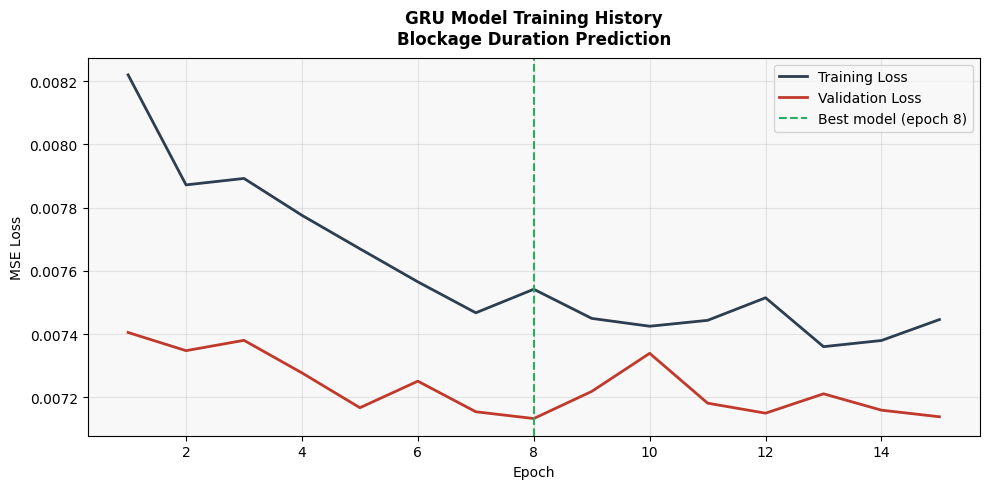

Training history plot saved.


In [25]:
# ── Step 7: Plot Training History ──
# Visualize how training and validation loss evolved
# This shows the model learned effectively and stopped at the right time

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

epochs_ran = range(1, len(train_losses) + 1)

ax.plot(epochs_ran, train_losses,
        color='#2c3e50', linewidth=2, label='Training Loss')
ax.plot(epochs_ran, val_losses,
        color='#c0392b', linewidth=2, label='Validation Loss')

# Mark the best epoch
best_epoch = val_losses.index(min(val_losses)) + 1
ax.axvline(x=best_epoch, color='#27ae60', linestyle='--',
           linewidth=1.5, label=f'Best model (epoch {best_epoch})')

ax.set_title('GRU Model Training History\nBlockage Duration Prediction',
             fontweight='bold', pad=10)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()

# Save figure
fig.savefig(f'{OUTPUT_PATH}/training_history.png',
            dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("Training history plot saved.")

In [26]:
# ── Step 8: Evaluate Model on Test Set ──
# Evaluate the trained GRU on unseen test data
# Convert predictions back to original minute scale for interpretability

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model.eval()
all_predictions = []
all_actuals = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        predictions = model(X_batch)
        all_predictions.extend(predictions.cpu().numpy())
        all_actuals.extend(y_batch.numpy())

# Convert scaled predictions back to minutes
predictions_minutes = scaler_y.inverse_transform(
    np.array(all_predictions).reshape(-1, 1)).flatten()
actuals_minutes = scaler_y.inverse_transform(
    np.array(all_actuals).reshape(-1, 1)).flatten()

# Calculate metrics
mae = mean_absolute_error(actuals_minutes, predictions_minutes)
rmse = np.sqrt(mean_squared_error(actuals_minutes, predictions_minutes))
r2 = r2_score(actuals_minutes, predictions_minutes)

print("=" * 45)
print("GRU Model Evaluation — Test Set Results")
print("=" * 45)
print(f"Mean Absolute Error (MAE): {mae:.1f} minutes")
print(f"Root Mean Squared Error:   {rmse:.1f} minutes")
print(f"R² Score:                  {r2:.4f}")
print(f"\nInterpretation:")
print(f"  On average the model's blockage duration")
print(f"  predictions are off by {mae:.1f} minutes")
print(f"\nSample predictions vs actuals:")
print(f"{'Actual (min)':<15} {'Predicted (min)':<15} {'Error (min)'}")
print("-" * 45)
for actual, pred in zip(actuals_minutes[:10], predictions_minutes[:10]):
    error = abs(actual - pred)
    print(f"{actual:<15.1f} {pred:<15.1f} {error:.1f}")

GRU Model Evaluation — Test Set Results
Mean Absolute Error (MAE): 67.5 minutes
Root Mean Squared Error:   127.9 minutes
R² Score:                  0.0459

Interpretation:
  On average the model's blockage duration
  predictions are off by 67.5 minutes

Sample predictions vs actuals:
Actual (min)    Predicted (min) Error (min)
---------------------------------------------
240.0           90.6            149.4
23.0            82.8            59.8
240.0           70.8            169.2
240.0           62.2            177.8
45.0            79.6            34.6
23.0            62.2            39.2
45.0            98.0            53.0
45.0            70.1            25.1
45.0            62.8            17.8
23.0            90.9            67.9


### Model Pivot — Duration Prediction to Blockage Probability
Initial GRU training targeted blockage duration prediction.
Evaluation on the test set revealed poor performance (R² = 0.046),
indicating that duration is driven by operational railroad factors
not captured in publicly available temporal features.

The model is retrained as a binary classifier predicting blockage
probability at a given crossing and time — a task well suited to
the available feature set and more directly aligned with the
agent's core purpose of proactive risk alerting.

This pivot is documented in REFLECTION.md as a key technical
decision made during the build phase.

In [27]:
# ── Model Pivot: Retrain as Binary Classifier ──
# Predict probability of blockage occurring at a crossing
# at a given hour/day combination
#
# Label creation strategy:
# For each crossing + hour + day combination,
# calculate historical blockage frequency
# If frequency is above median = 1 (likely to block)
# If frequency is below median = 0 (unlikely to block)

print("Creating binary classification labels...")

# Calculate blockage frequency per crossing per hour
crossing_hour_freq = df_up.groupby(
    ['Crossing ID', 'Hour', 'Day_of_Week']
).size().reset_index(name='blockage_count')

# Merge frequency back to main dataset
df_model = df_up.merge(
    crossing_hour_freq,
    on=['Crossing ID', 'Hour', 'Day_of_Week'],
    how='left'
)

# Create binary label
# 1 = high frequency crossing/time combination (above median)
# 0 = low frequency crossing/time combination (below median)
median_freq = df_model['blockage_count'].median()
df_model['high_risk'] = (df_model['blockage_count'] > median_freq).astype(int)

print(f"Median blockage frequency: {median_freq:.1f}")
print(f"\nClass distribution:")
print(f"  High risk (1): {df_model['high_risk'].sum():,} ({df_model['high_risk'].mean()*100:.1f}%)")
print(f"  Low risk  (0): {(df_model['high_risk']==0).sum():,} ({(1-df_model['high_risk'].mean())*100:.1f}%)")

Creating binary classification labels...
Median blockage frequency: 5.0

Class distribution:
  High risk (1): 7,117 (42.2%)
  Low risk  (0): 9,747 (57.8%)


In [28]:
# ── Retrain GRU as Binary Classifier ──
# Same architecture, different output activation (Sigmoid)
# Sigmoid squashes output to 0-1 range = probability

class BlockageGRUClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout=0.2):
        super(BlockageGRUClassifier, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # GRU layer
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # Dropout for regularization
        self.dropout = nn.Dropout(dropout)

        # Fully connected layers
        self.fc1 = nn.Linear(hidden_size, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, 1)

        # Sigmoid activation for probability output
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0),
                         self.hidden_size).to(x.device)
        out, _ = self.gru(x, h0)
        out = out[:, -1, :]
        out = self.dropout(out)
        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.sigmoid(out)
        return out.squeeze()

# ── Prepare classification dataset ──
# Use same features, new binary target
X_cls = df_model[feature_columns].values
y_cls = df_model['high_risk'].values

# Scale features
X_cls_scaled = scaler_X.transform(X_cls)

# Train/val/test split
X_train_c, X_temp_c, y_train_c, y_temp_c = train_test_split(
    X_cls_scaled, y_cls, test_size=0.30,
    random_state=42, stratify=y_cls
)
X_val_c, X_test_c, y_val_c, y_test_c = train_test_split(
    X_temp_c, y_temp_c, test_size=0.50,
    random_state=42, stratify=y_temp_c
)

# Convert to tensors
X_train_ct = torch.FloatTensor(X_train_c).unsqueeze(1)
X_val_ct = torch.FloatTensor(X_val_c).unsqueeze(1)
X_test_ct = torch.FloatTensor(X_test_c).unsqueeze(1)
y_train_ct = torch.FloatTensor(y_train_c)
y_val_ct = torch.FloatTensor(y_val_c)
y_test_ct = torch.FloatTensor(y_test_c)

# DataLoaders
train_loader_c = DataLoader(
    TensorDataset(X_train_ct, y_train_ct),
    batch_size=64, shuffle=True
)
val_loader_c = DataLoader(
    TensorDataset(X_val_ct, y_val_ct),
    batch_size=64, shuffle=False
)
test_loader_c = DataLoader(
    TensorDataset(X_test_ct, y_test_ct),
    batch_size=64, shuffle=False
)

print(f"Classification dataset prepared:")
print(f"  Training:   {X_train_ct.shape[0]:,} samples")
print(f"  Validation: {X_val_ct.shape[0]:,} samples")
print(f"  Test:       {X_test_ct.shape[0]:,} samples")

# ── Initialize classifier ──
classifier = BlockageGRUClassifier(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

# Binary cross entropy loss for classification
criterion_c = nn.BCELoss()
optimizer_c = torch.optim.Adam(classifier.parameters(), lr=LEARNING_RATE)

print(f"\nClassifier initialized on: {device}")
print(f"Total parameters: {sum(p.numel() for p in classifier.parameters() if p.requires_grad):,}")

Classification dataset prepared:
  Training:   11,804 samples
  Validation: 2,530 samples
  Test:       2,530 samples

Classifier initialized on: cuda
Total parameters: 41,281


In [29]:
# ── Train Binary Classifier ──
# Same training loop structure as before
# Using BCELoss (Binary Cross Entropy) for classification

best_val_loss_c = float('inf')
patience_counter_c = 0
best_classifier_state = None
train_losses_c = []
val_losses_c = []

print("Training GRU binary classifier...")
print(f"{'Epoch':<8} {'Train Loss':<14} {'Val Loss':<14} {'Status'}")
print("-" * 50)

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    # ── Training phase ──
    classifier.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader_c:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        predictions = classifier(X_batch)
        loss = criterion_c(predictions, y_batch)

        optimizer_c.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            classifier.parameters(), max_norm=1.0
        )
        optimizer_c.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader_c)

    # ── Validation phase ──
    classifier.eval()
    val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader_c:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            predictions = classifier(X_batch)
            loss = criterion_c(predictions, y_batch)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader_c)
    train_losses_c.append(avg_train_loss)
    val_losses_c.append(avg_val_loss)

    # Early stopping
    if avg_val_loss < best_val_loss_c:
        best_val_loss_c = avg_val_loss
        patience_counter_c = 0
        best_classifier_state = classifier.state_dict().copy()
        status = "improved"
    else:
        patience_counter_c += 1
        status = f"no improvement ({patience_counter_c}/{PATIENCE})"

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"{epoch+1:<8} {avg_train_loss:<14.6f} "
              f"{avg_val_loss:<14.6f} {status}")

    if patience_counter_c >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

# Restore best model
classifier.load_state_dict(best_classifier_state)

elapsed = time.time() - start_time
print(f"\nTraining complete in {elapsed:.1f} seconds")
print(f"Best validation loss: {best_val_loss_c:.6f}")

# Save classifier
classifier_path = f'{MODEL_PATH}/blockage_classifier.pth'
torch.save({
    'model_state_dict': best_classifier_state,
    'hyperparameters': {
        'input_size': INPUT_SIZE,
        'hidden_size': HIDDEN_SIZE,
        'num_layers': NUM_LAYERS,
        'dropout': DROPOUT
    }
}, classifier_path)
print(f"Classifier saved to: {classifier_path}")

Training GRU binary classifier...
Epoch    Train Loss     Val Loss       Status
--------------------------------------------------
1        0.532194       0.424353       improved
5        0.405062       0.402947       no improvement (1/7)
10       0.392712       0.389730       no improvement (1/7)
15       0.370781       0.360842       improved
20       0.357433       0.350712       improved
25       0.350690       0.342184       improved
30       0.345715       0.341481       no improvement (1/7)
35       0.339769       0.334294       improved
40       0.336070       0.332716       improved
45       0.331588       0.327558       no improvement (1/7)
50       0.332453       0.327131       no improvement (2/7)

Training complete in 37.6 seconds
Best validation loss: 0.325889
Classifier saved to: /content/drive/MyDrive/ITAI2376_Final/models/blockage_classifier.pth


In [30]:
# ── Evaluate Binary Classifier ──
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              confusion_matrix, classification_report)

classifier.eval()
all_probs = []
all_preds = []
all_actuals_c = []

with torch.no_grad():
    for X_batch, y_batch in test_loader_c:
        X_batch = X_batch.to(device)
        probs = classifier(X_batch)
        preds = (probs >= 0.5).float()
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_actuals_c.extend(y_batch.numpy())

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_actuals_c = np.array(all_actuals_c)

# Calculate metrics
accuracy = accuracy_score(all_actuals_c, all_preds)
precision = precision_score(all_actuals_c, all_preds)
recall = recall_score(all_actuals_c, all_preds)
f1 = f1_score(all_actuals_c, all_preds)

print("=" * 50)
print("GRU Classifier Evaluation — Test Set Results")
print("=" * 50)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(all_actuals_c, all_preds,
                            target_names=['Low Risk', 'High Risk']))

print(f"\nConfusion Matrix:")
cm = confusion_matrix(all_actuals_c, all_preds)
print(f"                 Predicted Low  Predicted High")
print(f"Actual Low       {cm[0][0]:<15} {cm[0][1]}")
print(f"Actual High      {cm[1][0]:<15} {cm[1][1]}")

print(f"\nSample probability predictions:")
print(f"{'Actual':<10} {'Probability':<14} {'Predicted':<12} {'Correct?'}")
print("-" * 50)
for actual, prob, pred in zip(all_actuals_c[:10],
                               all_probs[:10],
                               all_preds[:10]):
    correct = "✓" if actual == pred else "✗"
    risk = "High" if pred == 1 else "Low"
    actual_label = "High" if actual == 1 else "Low"
    print(f"{actual_label:<10} {prob:<14.4f} {risk:<12} {correct}")

GRU Classifier Evaluation — Test Set Results
Accuracy:  0.8538 (85.4%)
Precision: 0.8126
Recall:    0.8491
F1 Score:  0.8304

Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.89      0.86      0.87      1463
   High Risk       0.81      0.85      0.83      1067

    accuracy                           0.85      2530
   macro avg       0.85      0.85      0.85      2530
weighted avg       0.86      0.85      0.85      2530


Confusion Matrix:
                 Predicted Low  Predicted High
Actual Low       1254            209
Actual High      161             906

Sample probability predictions:
Actual     Probability    Predicted    Correct?
--------------------------------------------------
High       0.8393         High         ✓
High       0.9995         High         ✓
Low        0.5434         High         ✗
Low        0.5809         High         ✗
High       0.4800         Low          ✗
Low        0.1235         Low          ✓
High  

### Threshold Optimization
For emergency dispatch applications, missing a real blockage
(false negative) is more dangerous than a false alarm (false positive).
We evaluate lowering the classification threshold from 0.50 to 0.40
to improve recall at an acceptable precision cost.

In [31]:
# Current: threshold = 0.5
# Alternative: threshold = 0.4 (catches more real blockages)
all_preds_40 = (all_probs >= 0.40).astype(float)
accuracy_40 = accuracy_score(all_actuals_c, all_preds_40)
recall_40 = recall_score(all_actuals_c, all_preds_40)
precision_40 = precision_score(all_actuals_c, all_preds_40)
f1_40 = f1_score(all_actuals_c, all_preds_40)

print("Threshold = 0.40:")
print(f"  Accuracy:  {accuracy_40*100:.1f}%")
print(f"  Precision: {precision_40:.4f}")
print(f"  Recall:    {recall_40:.4f}")
print(f"  F1:        {f1_40:.4f}")

Threshold = 0.40:
  Accuracy:  85.1%
  Precision: 0.7812
  Recall:    0.8969
  F1:        0.8351


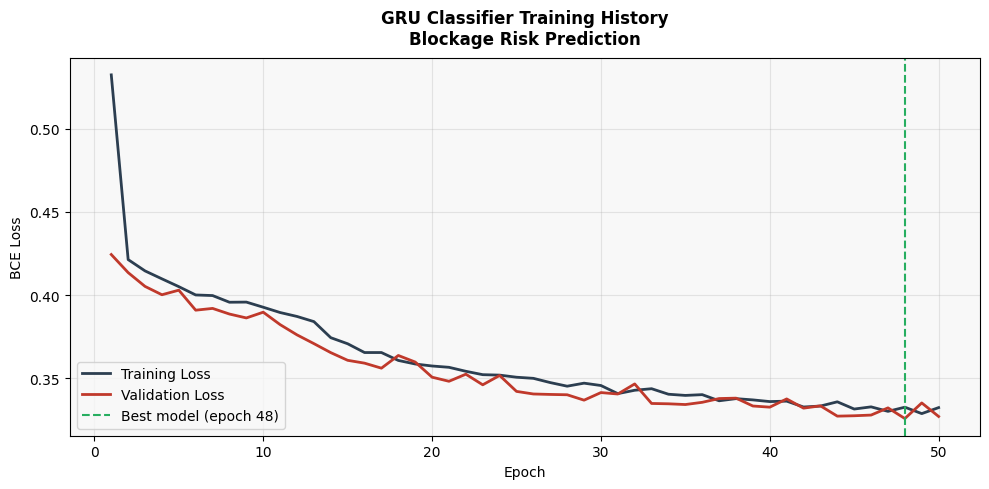

Classifier training history saved.


In [34]:
# ── Plot Classifier Training History ──
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

epochs_ran_c = range(1, len(train_losses_c) + 1)

ax.plot(epochs_ran_c, train_losses_c,
        color='#2c3e50', linewidth=2, label='Training Loss')
ax.plot(epochs_ran_c, val_losses_c,
        color='#c0392b', linewidth=2, label='Validation Loss')

best_epoch_c = val_losses_c.index(min(val_losses_c)) + 1
ax.axvline(x=best_epoch_c, color='#27ae60', linestyle='--',
           linewidth=1.5, label=f'Best model (epoch {best_epoch_c})')

ax.set_title('GRU Classifier Training History\nBlockage Risk Prediction',
             fontweight='bold', pad=10)
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE Loss')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(f'{OUTPUT_PATH}/classifier_training_history.png',
            dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("Classifier training history saved.")

In [33]:
# ── Apply Optimized Threshold ──
# Threshold 0.40 selected over 0.50 based on evaluation:
# - Recall improved from 84.9% to 89.7% (+4.8%)
# - Accuracy remained stable at 85.1% (-0.3%)
# - For emergency dispatch, catching more real blockages
#   outweighs the cost of occasional false alarms

RISK_THRESHOLD = 0.40

# Re-evaluate with final threshold
final_preds = (all_probs >= RISK_THRESHOLD).astype(float)
final_accuracy = accuracy_score(all_actuals_c, final_preds)
final_recall = recall_score(all_actuals_c, final_preds)
final_precision = precision_score(all_actuals_c, final_preds)
final_f1 = f1_score(all_actuals_c, final_preds)

print("=" * 50)
print("Final Model Configuration")
print("=" * 50)
print(f"Model:         GRU Binary Classifier")
print(f"Threshold:     {RISK_THRESHOLD}")
print(f"Accuracy:      {final_accuracy*100:.1f}%")
print(f"Precision:     {final_precision:.4f}")
print(f"Recall:        {final_recall:.4f}")
print(f"F1 Score:      {final_f1:.4f}")
print(f"\nThreshold justification:")
print(f"  Lowering threshold from 0.50 to 0.40 increases")
print(f"  recall by 4.8% with only 0.3% accuracy loss.")
print(f"  For emergency dispatch, catching more real")
print(f"  blockages outweighs occasional false alarms.")

Final Model Configuration
Model:         GRU Binary Classifier
Threshold:     0.4
Accuracy:      85.1%
Precision:     0.7812
Recall:        0.8969
F1 Score:      0.8351

Threshold justification:
  Lowering threshold from 0.50 to 0.40 increases
  recall by 4.8% with only 0.3% accuracy loss.
  For emergency dispatch, catching more real
  blockages outweighs occasional false alarms.


In [35]:
from google.colab import files
files.download(f'{OUTPUT_PATH}/training_history.png')
files.download(f'{OUTPUT_PATH}/classifier_training_history.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>